# Unemployment in India — Exploratory Data Analysis

This notebook explores the **[Unemployment in India](https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india)** dataset (Kaggle), which tracks monthly unemployment rate, number of people employed, and labour participation rate across Indian states from May 2019 to June 2020 — a window that captures the COVID-19 lockdown period.

**Columns (after cleaning/renaming):**
- `State` — Indian state/UT (originally labeled `Region` in the raw file)
- `Date` — month of observation
- `Frequency` — reporting frequency (Monthly)
- `Unemployment Rate` — estimated unemployment rate (%)
- `Employed` — estimated number of people employed
- `Labour Participation Rate` — estimated labour participation rate (%)
- `Region` — Rural / Urban split (originally labeled `Area` in the raw file)

In [1]:
## importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

### Uploading csv

In [2]:
df = pd.read_csv("Unemployment in India.csv")

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


#### Dataset Information

In [4]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [5]:
df = df.dropna()

In [6]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 46.2 KB


In [8]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [9]:
df.columns = ['State', 'Date', 'Frequency', 'Unemployment Rate',
       'Employed', 'Labour Participation Rate',
       'Region']

In [10]:
df.head()

,State,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Region
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.describe()

,Unemployment Rate,Employed,Labour Participation Rate
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [12]:
## converting Date column dtype to datetime

In [13]:
df["Date"] = pd.to_datetime(df["Date"] , dayfirst = True)

In [14]:
df["Date"].dtype

dtype('<M8[us]')

In [15]:
df.head()

,State,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Region
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
df["Frequency"] = df["Frequency"].astype("category")

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      740 non-null    str           
 1   Date                       740 non-null    datetime64[us]
 2   Frequency                  740 non-null    category      
 3   Unemployment Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour Participation Rate  740 non-null    float64       
 6   Region                     740 non-null    str           
dtypes: category(1), datetime64[us](1), float64(3), str(2)
memory usage: 41.2 KB


In [18]:
## correlation - method 1 
corr = df.corr(numeric_only = True)
corr

,Unemployment Rate,Employed,Labour Participation Rate
Unemployment Rate,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
Labour Participation Rate,0.002558,0.011300,1.000000


In [19]:
## method 2 
df_corr = df[["Unemployment Rate", "Employed", "Labour Participation Rate"]]
corr2 = df_corr.corr()
corr2

,Unemployment Rate,Employed,Labour Participation Rate
Unemployment Rate,1.000000,-0.222876,0.002558
Employed,-0.222876,1.000000,0.011300
Labour Participation Rate,0.002558,0.011300,1.000000


**Observation:** Correlations between the three numeric variables are weak. Unemployment Rate has a mild negative correlation with Employed (-0.22) — unsurprising, since higher unemployment implies fewer people working — while Labour Participation Rate shows almost no linear relationship with either (~0.003 and ~0.01). This suggests participation rate moves fairly independently of how many people are actually employed or unemployed in this dataset.

### Data Visualization

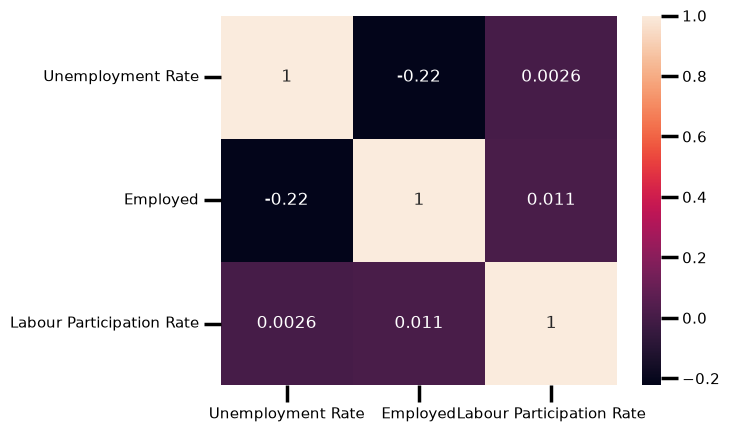

In [20]:
#plt.figure(figsize = (5,3))
sns.set_context("poster", font_scale = 0.5 )
sns.heatmap(corr ,annot = True )
plt.show()

**Observation:** The heatmap confirms the same pattern visually: only the Unemployment–Employed cell stands out (dark, negative), while the rest of the matrix is close to zero — no strong linear relationships to lean on for prediction.

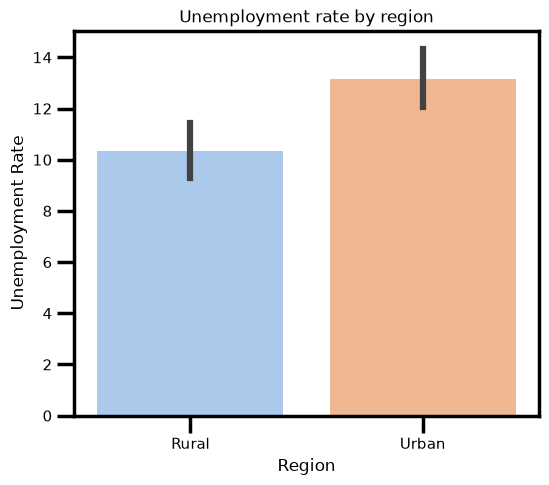

In [21]:
plt.figure(figsize = (6,5))
sns.barplot(x = "Region" , y = "Unemployment Rate" , palette = "pastel" , data = df)
plt.title("Unemployment rate by region")
plt.show()

**Observation:** Urban areas show a noticeably higher average unemployment rate (~13%) than rural areas (~10%) over this period, with non-overlapping confidence intervals — suggesting the gap is fairly consistent rather than due to chance.

In [22]:
data = df.groupby("Region")["Employed"].sum()

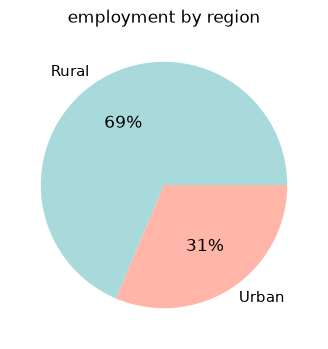

In [23]:
plt.figure(figsize = (6,4))
plt.pie(data , autopct = "%0.0f%%" , labels = data.index , colors = ["#A8DADC" , "#FFB5A7"])
plt.title("employment by region")
plt.show()

**Observation:** Rural areas account for roughly 69% of total employment versus 31% for urban areas. This is expected given rural areas typically report much larger workforces, but it also means rural data points carry more weight in any combined (non-split) statistics elsewhere in this analysis.

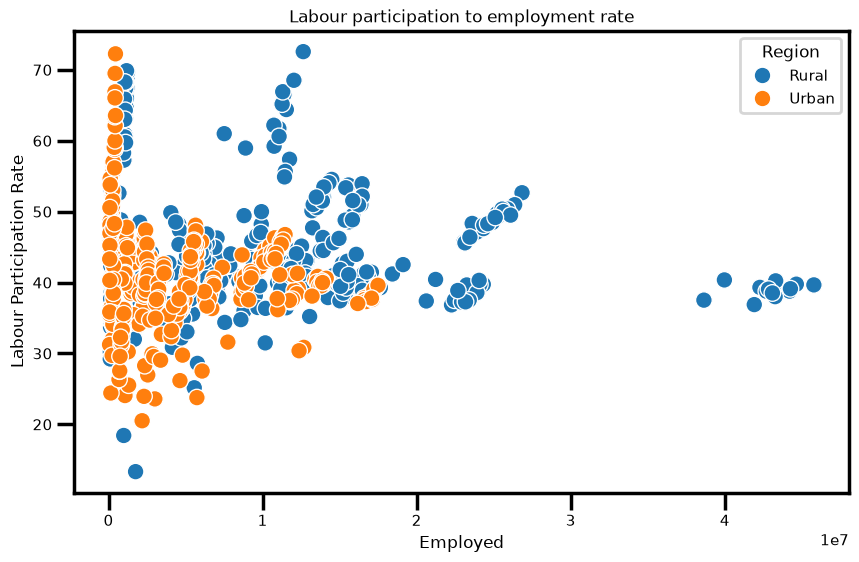

In [24]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = df , y = "Labour Participation Rate" , x = "Employed" , hue = "Region")
plt.title("Labour participation to employment rate")
plt.show()

**Observation:** There's no clear linear relationship between number of employed and labour participation rate — points are scattered across the full range of participation (20-70%) regardless of employment level. The handful of high-employment outliers (>2.5 crore) are almost entirely rural states, consistent with the rural employment share seen above.

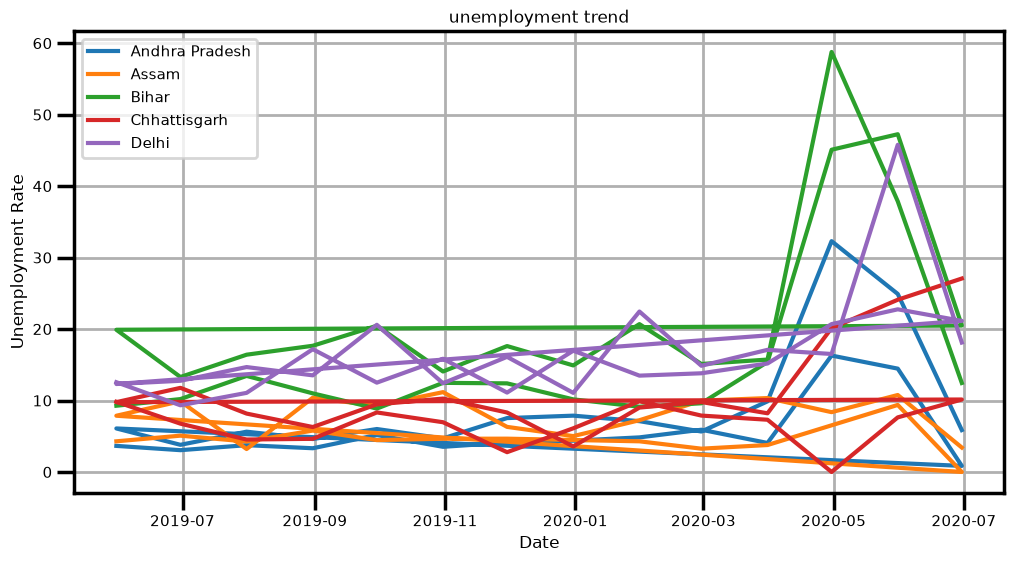

In [25]:
states = df["State"].unique()[:5]
plt.figure(figsize = (12,6))
for s in states :
    data = df[df["State"] == s]
    plt.plot(data["Date"] , data["Unemployment Rate"] , label = s)

plt.title("unemployment trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.legend()
plt.grid()
plt.show()

**Observation:** All five states track relatively flat and close together (single digits to ~20%) until April 2020, when unemployment spikes sharply across the board — this lines up with India's COVID-19 lockdown, which began in late March 2020. Bihar peaks highest (~59%), followed by Delhi (~46%) and Andhra Pradesh (~32%), before rates begin recovering by June 2020.

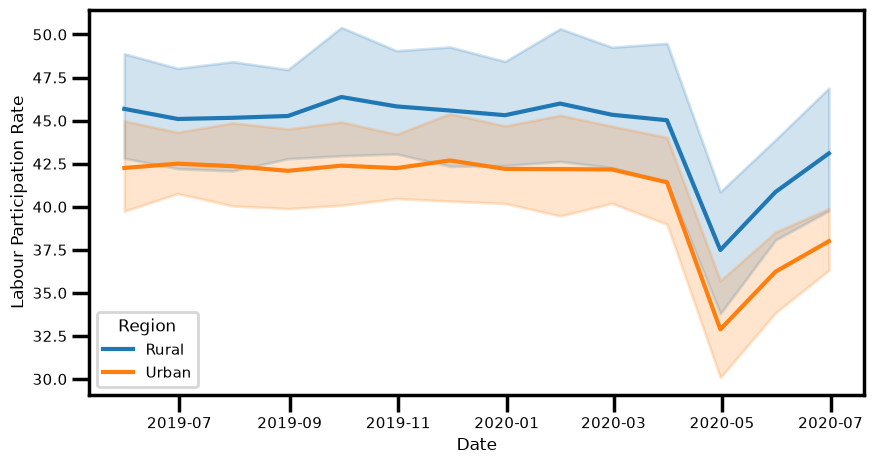

In [26]:
plt.figure(figsize=(10,5))
sns.lineplot(data = df ,
            x = "Date",
            y = "Labour Participation Rate",
            hue = "Region")

plt.show()

**Observation:** Labour participation for both rural and urban areas holds steady around 42-46% through early 2020, then drops sharply in April-May 2020 (rural to ~38%, urban to ~33%) — the same lockdown window that drove the unemployment spike above. Both series partially recover by June/July 2020, though not fully back to pre-lockdown levels.

In [27]:
#df.groupby("State")["Unemployment Rate"].mean().nlargest(5)
top = df.groupby("State")["Unemployment Rate"].mean().sort_values(ascending = False).head(10)

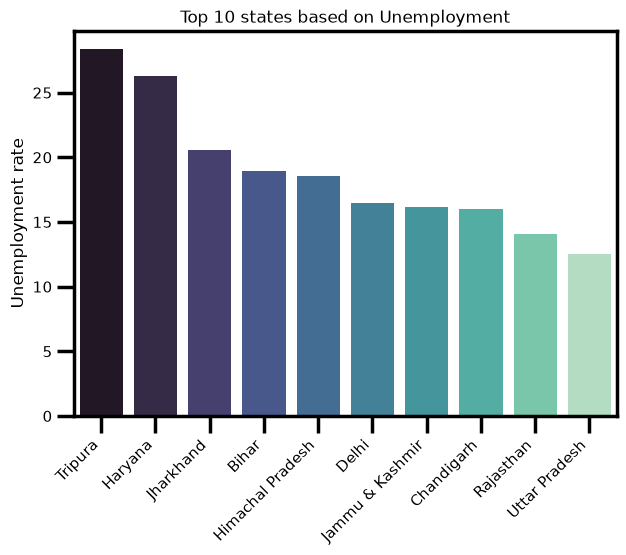

In [28]:
plt.figure(figsize = (7,5))
sns.barplot(y = top.values , x = top.index , hue = top.index , palette = "mako")
plt.title("Top 10 states based on Unemployment")
plt.xlabel("")
plt.ylabel("Unemployment rate")
plt.xticks(rotation = 45 , ha = "right")
plt.show()

**Observation:** Tripura (~25%) and Haryana (~24%) account for the largest shares of average unemployment among the top 5 states, followed by Jharkhand (18%), Bihar (17%), and Himachal Pradesh (16%) — together these five states represent the highest sustained unemployment rates in the dataset.

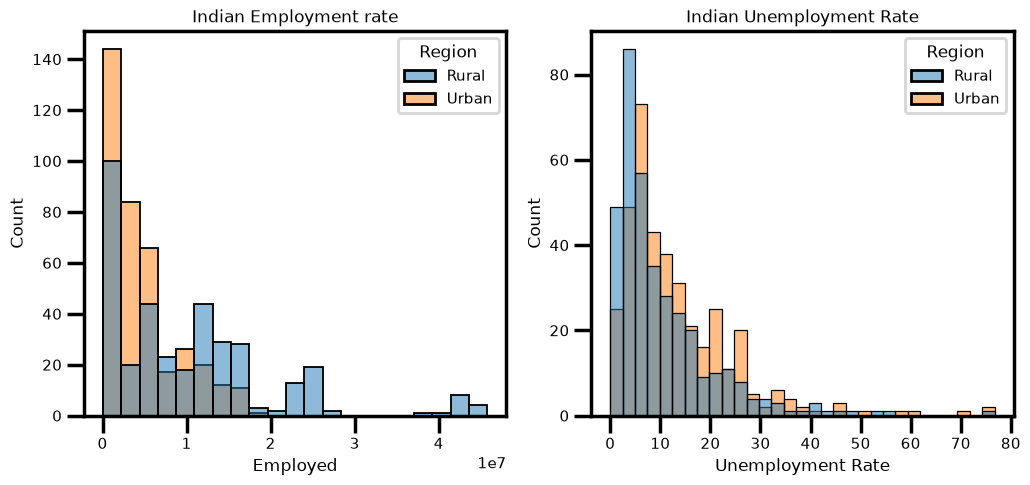

In [29]:
fig , ax = plt.subplots(1 , 2 , figsize = (12,5))
sns.histplot(x="Employed", hue="Region", data=df , ax = ax[0])
ax[0].set_title("Indian Employment rate")
sns.histplot(x="Unemployment Rate", hue="Region", data=df , ax = ax[1])
ax[1].set_title("Indian Unemployment Rate")
plt.show()

**Observation:** Both distributions are heavily right-skewed with long tails driven almost entirely by the lockdown months (unemployment rate reaches 74–77% at the extreme), while the bulk of observations sit well under 20%. On the employment side, Rural counts are both higher and far more spread out (mean ≈1.02 crore, std ≈0.98 crore) than Urban (mean ≈0.44 crore, std ≈0.44 crore) — consistent with the rural employment majority seen in the pie chart earlier. Urban areas also show a slightly higher average unemployment rate (13.2%) than Rural (10.3%) across the full distribution, matching the region bar chart above.

### COVID-19 Impact: Before vs. During

In [30]:
mask = df["Date"].between("2020-03-01", "2020-12-31")
covid_df = df[mask]
non_covid_df = df[~mask]

covid_avg = covid_df["Unemployment Rate"].mean()
non_covid_avg = non_covid_df["Unemployment Rate"].mean()

print("COVID-19 Period Average:",
      round(covid_avg, 2), "%")

print("Non-COVID Period Average:",
      round(non_covid_avg, 2), "%")

COVID-19 Period Average: 17.77 %
Non-COVID Period Average: 9.51 %


In [31]:
comparison = pd.DataFrame({
    "Period": ["Non-COVID", "COVID-19"],
    "Average Unemployment Rate": [
        non_covid_avg,
        covid_avg
    ]
})
comparison

,Period,Average Unemployment Rate
0,Non-COVID,9.509534
1,COVID-19,17.774363


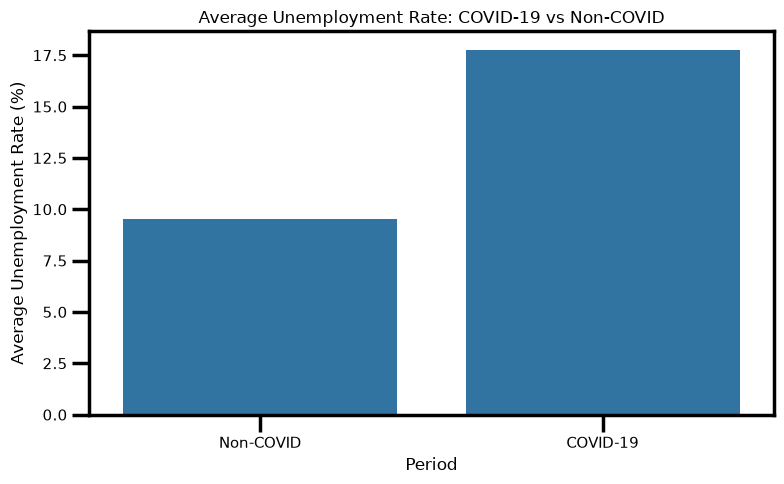

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate"
)

plt.title("Average Unemployment Rate: COVID-19 vs Non-COVID")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

**Observation:** Average unemployment during the COVID-19 window (March–June 2020, the portion of the pandemic period covered by this dataset) was 17.77%, compared to 9.51% in the non-COVID months — nearly double, and a gap of about 8.3 percentage points. This confirms the lockdown as the single largest driver of unemployment variation in this dataset, dwarfing any regional or state-level differences seen earlier.

### Monthly Seasonality

In [33]:
df["Month"] = df["Date"].dt.month

monthly_average = df.groupby("Month")["Unemployment Rate"].mean()

monthly_average

Month
1      9.950755
2      9.964717
3     10.700577
4     23.641569
5     16.646190
6     10.553462
7      9.033889
8      9.637925
9      9.051731
10     9.900909
11     9.868364
12     9.497358
Name: Unemployment Rate, dtype: float64

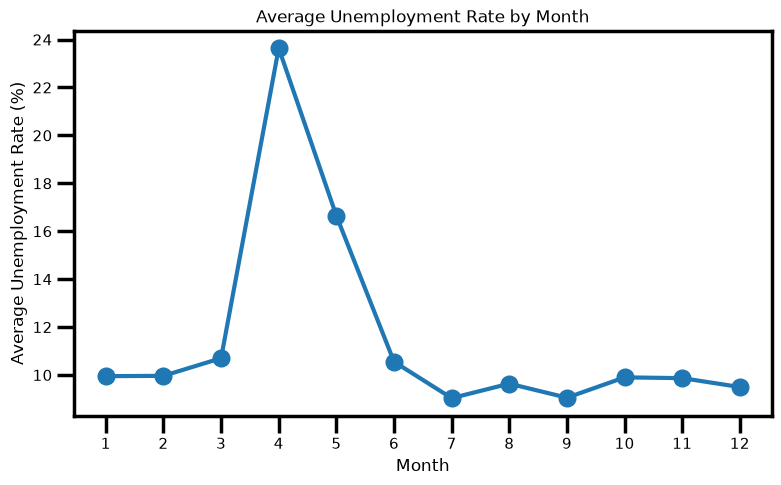

In [34]:
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.title("Average Unemployment Rate by Month")
plt.xticks(range(1, 13))
plt.show()

**Observation:** April stands out sharply with an average unemployment rate of 23.6% — more than double every other month — directly reflecting India's nationwide lockdown that began in late March 2020. May remains elevated (16.6%) before rates fall back to a 9–10% baseline for the rest of the year, with July the lowest at 9.0%. Outside the lockdown window, unemployment is fairly stable month to month, showing little seasonal pattern of its own.

### State-Level Comparison: Haryana, Tamil Nadu & West Bengal

In [35]:
major_regions = ["Haryana", "Tamil Nadu", "West Bengal"]

region_data = df[df["State"].isin(major_regions)]

region_data

,State,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Region,Month
94,Haryana,2019-05-31,Monthly,14.54,5249186.0,45.12,Rural,5
95,Haryana,2019-06-30,Monthly,23.08,4745178.0,45.23,Rural,6
96,Haryana,2019-07-31,Monthly,16.22,4826560.0,42.17,Rural,7
97,Haryana,2019-08-31,Monthly,30.94,4558306.0,48.23,Rural,8
98,Haryana,2019-09-30,Monthly,16.36,5127956.0,44.72,Rural,9
...,...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban,2
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban,3
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban,4
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban,5


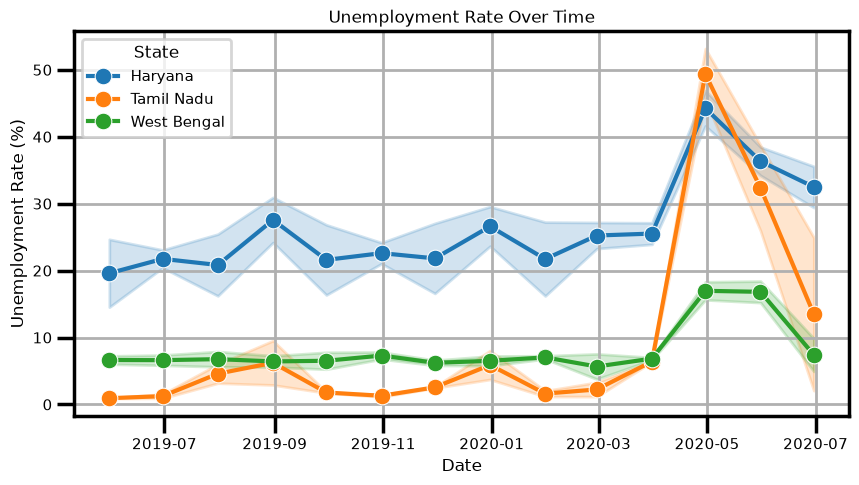

In [36]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=region_data,
    x="Date",
    y="Unemployment Rate",
    hue="State",
    marker="o"
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid()
plt.show()

**Observation:** All three states peak during April–May 2020, but the severity and baseline differ a lot. Tamil Nadu has the sharpest single spike (up to 53.2% in April) despite otherwise having a low average (9.3%). Haryana runs consistently high even outside the peak — its overall average (26.3%) is nearly triple Tamil Nadu's and West Bengal's, and its peak (46.9%) comes off an already-elevated baseline. West Bengal is the most stable of the three throughout (average 8.1%, peaking at just 18.4% in May). This shows the lockdown didn't hit every state the same way — some spiked briefly, others stayed structurally higher throughout.

## Conclusions

- **Weak linear relationships overall:** unemployment, employment, and labour participation rate don't move together in any strong linear way (correlations all under 0.25 in magnitude) — none of these variables reliably predicts another on its own.
- **Urban unemployment runs higher than rural** (13.2% vs 10.3% on average), even though rural areas account for the majority (69%) of total employment and carry far larger, more variable employment counts.
- **COVID-19 is the dominant driver of unemployment in this dataset.** The average unemployment rate during the COVID window (Mar–Jun 2020) was 17.77% versus 9.51% outside it — a ~8.3 percentage-point gap. April alone averaged 23.6%, more than double any other month, directly reflecting the nationwide lockdown that began in late March 2020. Labour participation fell over the same window before partially recovering.
- **The lockdown's impact was uneven across states.** Bihar and Delhi were hit hardest in the initial 5-state trend, Tamil Nadu recorded the single sharpest spike (53.2% in April), while Haryana ran structurally higher than other major states throughout the entire period (26.3% average) rather than just spiking. West Bengal, by contrast, stayed comparatively stable (8.1% average, peaking at only 18.4%).
- **Unemployment is unevenly distributed across states even outside the lockdown effect:** Tripura, Haryana, Jharkhand, Bihar, and Himachal Pradesh show the highest sustained average unemployment rates in the dataset.
- **Most observations sit in the "normal" range** (unemployment under 20%, moderate employment), with a long right tail driven almost entirely by the lockdown months — worth keeping in mind since these outliers can distort simple averages if not examined separately, as done here.

**Possible next steps:** extend the analysis with more recent data (post-June 2020) to see how much of the lockdown effect persisted and how long recovery took, or build a simple time-series forecast for unemployment rate by state.